In [133]:
#for saving images in px
%pip install plotly==5.18.0 kaleido==0.2.1

Note: you may need to restart the kernel to use updated packages.


In [134]:
#File from url:   https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=CSV%20format

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
df_original=pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\UN_project\WPP2024_Demographic_Indicators_Medium.csv",low_memory=False)


In [136]:
df_original.head(2)

,SortOrder,LocID,Notes,ISO3_code,ISO2_code,SDMX_code,LocTypeID,LocTypeName,ParentID,Location,...,Q0060Male,Q0060Female,Q1550,Q1550Male,Q1550Female,Q1560,Q1560Male,Q1560Female,NetMigrations,CNMR
0,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,654.5798,631.8067,297.6529,298.4483,297.2079,443.3215,457.3384,427.3167,201.196,2.907
1,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,642.5944,619.1788,292.4375,293.1236,292.0887,436.9979,451.4368,420.7398,195.070,2.760


In [137]:
df_original.select_dtypes(include=["number"]).head(2)

,SortOrder,LocID,SDMX_code,LocTypeID,ParentID,VarID,Time,TPopulation1Jan,TPopulation1July,TPopulationMale1July,...,Q0060Male,Q0060Female,Q1550,Q1550Male,Q1550Female,Q1560,Q1560Male,Q1560Female,NetMigrations,CNMR
0,NaN,5507,NaN,NaN,NaN,2,1950,68501.280,69213.424,35880.164,...,654.5798,631.8067,297.6529,298.4483,297.2079,443.3215,457.3384,427.3167,201.196,2.907
1,NaN,5507,NaN,NaN,NaN,2,1951,69925.568,70682.760,36615.258,...,642.5944,619.1788,292.4375,293.1236,292.0887,436.9979,451.4368,420.7398,195.070,2.760


In [138]:
df_original.select_dtypes(include=["object","category"]).head(2)


,Notes,ISO3_code,ISO2_code,LocTypeName,Location,Variant
0,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,Medium
1,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,Medium


Understanding the features:  

**ID / Location Features**  
SortOrder: Sorting order used by UN  
LocID: UN numeric code for country (Lebanon = 422)  
Location: Country/region name e.g. Lebanon, World, Western Asia  
ISO3_code: 3-letter code e.g. LBN  
ISO2_code: 2-letter code e.g. LB  
LocTypeID / LocTypeName: Is it Country, Region, or World  
ParentID: Parent region ID

**Time**  
Time: Year (1950 to 2100)  
Population  
TPopulation1Jan / TPopulation1July: Total population in thousands (mid-year)  
PopMale / PopFemale: Male/Female population  
PopDensity: People per km2  
MedianAgePop: Median age - if high, population is old  
PopChange: How many people added that year  
PopGrowthRate: Growth % that year  

**Births / Fertility**  
Births: Number of births (thousands)  
CBR: Crude Birth Rate - births per 1000 people  
TFR: Total Fertility Rate - average kids per woman (MOST IMPORTANT)  
NRR: Net Reproduction Rate  
Births1519: Births to mothers age 15-19  
SRB: Sex Ratio at Birth

**Deaths / Mortality**  
Deaths: Number of deaths (thousands)  
CDR: Crude Death Rate  
LEx: Life Expectancy at birth - both sexes  
LExMale / LExFemale: Life expectancy male/female  
IMR: Infant Mortality Rate  
Q5: Under-5 mortality rate  
CDRLT65 / CDRGT65: Death rates under 65 / over 65

**Migration**  
NetMigrations: Immigrants - Emigrants (negative = people leaving Lebanon)  
CNMR: Net Migration Rate

In [139]:
#For Lebanon we only need 6 features
df = df_original[df_original['ISO3_code']=='LBN'][['Time','TPopulation1July','PopGrowthRate','MedianAgePop','TFR','LEx','CBR','CDR','NetMigrations']]
df

,Time,TPopulation1July,PopGrowthRate,MedianAgePop,TFR,LEx,CBR,CDR,NetMigrations
61104,1950,1349.350,2.786,21.9593,5.8054,59.8999,41.164,13.300,0.000
61105,1951,1387.572,2.800,21.7235,5.8052,60.3297,41.119,13.130,0.000
61106,1952,1427.085,2.816,21.4871,5.7989,60.7644,40.987,12.829,0.000
61107,1953,1468.014,2.839,21.2387,5.8050,61.1769,40.899,12.512,0.000
61108,1954,1510.416,2.856,20.9757,5.8062,61.5877,40.736,12.178,0.000
...,...,...,...,...,...,...,...,...,...
61251,2097,7260.714,-0.334,47.0932,1.7524,87.2673,9.262,12.036,-4.134
61252,2098,7237.785,-0.298,47.1991,1.7480,87.3711,9.219,12.142,-0.418
61253,2099,7215.744,-0.312,47.2873,1.7482,87.4796,9.207,12.229,-0.698
61254,2100,7192.592,-0.331,47.3690,1.7468,87.5915,9.184,12.298,-1.399


**Features needed For Lebanon**  

-Time: Year (1950 to 2100)  
-TPopulation1July: Total population in thousands (mid-year)  
-PopGrowthRate: Growth % that year: PopGrowthRate = (Population this year - Population last year) / Population last year * 100  
-MedianAgePop: Median age - if high, population is old  
-TFR: Total Fertility Rate - average kids per woman (MOST IMPORTANT)  
-LEx: Life Expectancy at birth - both sexes  
-CBR: Crude Birth Rate - births per 1000 people  
-CDR: Crude Death Rate - deaths per 1000 people  
-NetMigrations: Immigrants - Emigrants (negative = people leaving Lebanon)  


In [140]:
df.isna().sum().sort_values(ascending=False)

TPopulation1July    1
PopGrowthRate       1
MedianAgePop        1
TFR                 1
LEx                 1
CBR                 1
CDR                 1
NetMigrations       1
Time                0
dtype: int64

In [141]:
print("Percentage of missing values:\n\n{}".format(df.isna().sum()/len(df)*100))

Percentage of missing values:

Time                0.000000
TPopulation1July    0.657895
PopGrowthRate       0.657895
MedianAgePop        0.657895
TFR                 0.657895
LEx                 0.657895
CBR                 0.657895
CDR                 0.657895
NetMigrations       0.657895
dtype: float64


In [142]:
#Since percentage of missing values is small, they can be dropped
df=df.dropna(subset=["TPopulation1July","PopGrowthRate","MedianAgePop","TFR","LEx","CBR","CDR","NetMigrations"])
df.isna().sum()

Time                0
TPopulation1July    0
PopGrowthRate       0
MedianAgePop        0
TFR                 0
LEx                 0
CBR                 0
CDR                 0
NetMigrations       0
dtype: int64

**1. Population Growth Analysis**

How did Lebanon’s total population change from 1950-2023?  
When was the fastest growth?  
What does UN project for 2030, 2050, 2100?

In [143]:
df.head(3)

,Time,TPopulation1July,PopGrowthRate,MedianAgePop,TFR,LEx,CBR,CDR,NetMigrations
61104,1950,1349.350,2.786,21.9593,5.8054,59.8999,41.164,13.300,0.0
61105,1951,1387.572,2.800,21.7235,5.8052,60.3297,41.119,13.130,0.0
61106,1952,1427.085,2.816,21.4871,5.7989,60.7644,40.987,12.829,0.0


In [144]:
df[["Time","TPopulation1July"]].sort_index()

,Time,TPopulation1July
61104,1950,1349.350
61105,1951,1387.572
61106,1952,1427.085
61107,1953,1468.014
61108,1954,1510.416
...,...,...
61250,2096,7284.840
61251,2097,7260.714
61252,2098,7237.785
61253,2099,7215.744


In [145]:
df_plot = df[["Time","TPopulation1July"]].sort_values("Time")
df_plot.head(2)

,Time,TPopulation1July
61104,1950,1349.350
61105,1951,1387.572


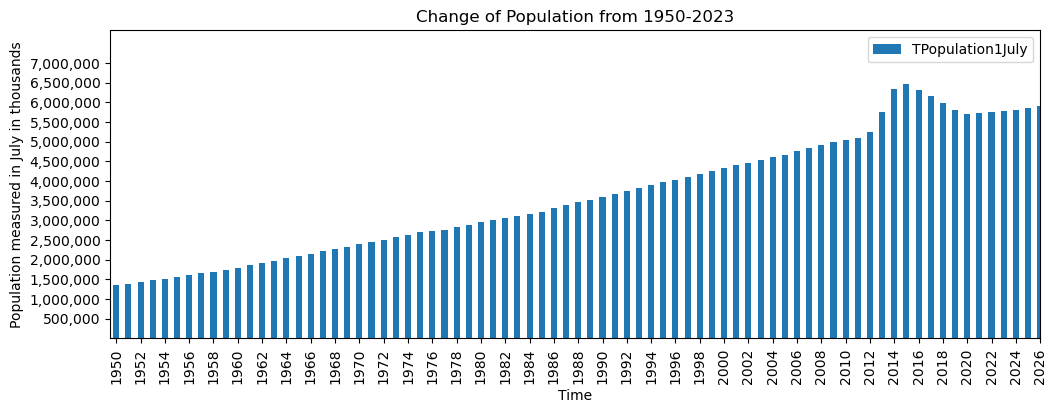

In [175]:
from matplotlib.ticker import FuncFormatter

df[["TPopulation1July","Time"]].sort_values("Time").plot(kind="bar",
                                                  x="Time",
                                                  y="TPopulation1July",
                                                  figsize=(12,4),
                                                 )

plt.xticks(range(0, 84, 2));
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xlim(-0.5,76)
plt.yticks(np.arange(0.5e6,7.5e6,500000)) 
plt.xlabel("Time"),
plt.ylabel("Population measured in July in thousands"),
plt.title("Change of Population from 1950-2023")
plt.savefig("Chart1_Population_growth.png", bbox_inches='tight')

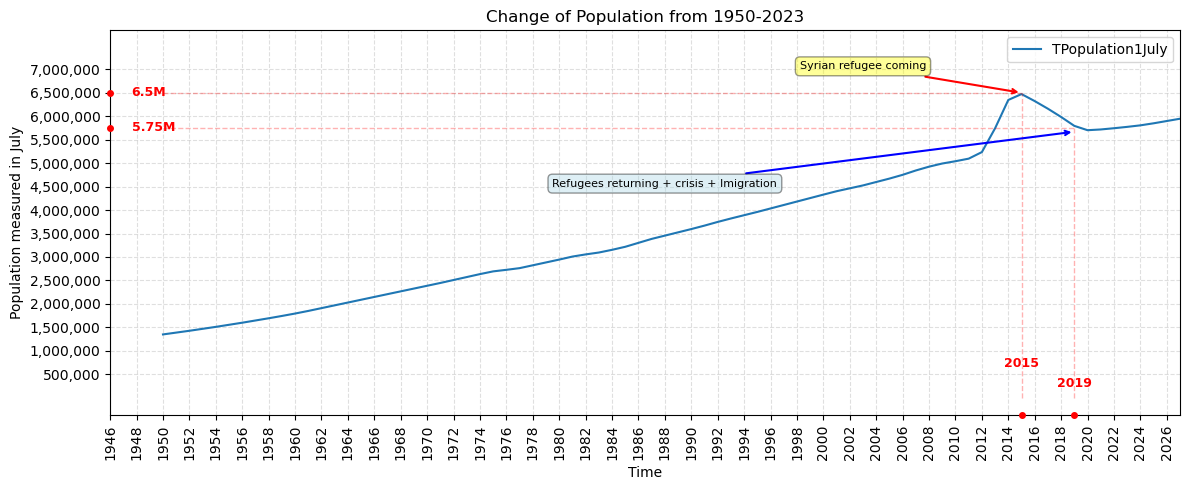

In [147]:
from matplotlib.ticker import FuncFormatter

ax=df[["TPopulation1July","Time"]].sort_index().plot(kind="line",x="Time",y="TPopulation1July",figsize=(12,5))
plt.xlabel("Time"),
plt.ylabel("Population measured in July"),
plt.title("Change of Population from 1950-2023")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(1950,2027)
plt.xticks(range(1946,2027,2),rotation=90)
plt.yticks(np.arange(0.5e6,7.5e6,500000)) 


plt.annotate('Syrian refugee coming',
             xy=(2015, 6.5e6), xytext=(2003, 7e6),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=8, ha='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.4))

ax.vlines( x=2015, ymin=0, ymax=6.5e6, color='red', linestyle='--', linewidth=1, alpha=0.3)
#plot a red dot and value in red
ax.plot(2015, 0, marker='o', color='red', markersize=4, transform=ax.get_xaxis_transform(), clip_on=False, zorder=5)
ax.text(2015,0.15, "2015", color='red', fontweight='bold', fontsize=9, ha='center', va='top', transform=ax.get_xaxis_transform(), clip_on=False)

ax.hlines( y=6.5e6, xmin=1950, xmax=2015, color='red', linestyle='--', linewidth=1, alpha=0.3)
ax.plot(0, 6.5e6, marker='o',color='red', markersize=4,transform=ax.get_yaxis_transform(), clip_on=False, zorder=5)
ax.text(0.02, 6.5e6, "6.5M", color='red', fontweight='bold', fontsize=9,ha='left', va='center', transform=ax.get_yaxis_transform(), clip_on=False)




# --- LABEL 2: 2015-2020 Drop ---
plt.annotate('Refugees returning + crisis + Imigration',
             xy=(2019, 5.67e6), xytext=(1988, 4.5e6),
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
             fontsize=8, ha='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="lightblue", alpha=0.4))
#vertical line
ax.vlines( x=2019, ymin=0, ymax=5.75e6, color='red', linestyle='--', linewidth=1, alpha=0.3)
#plot  dot and year
ax.plot(2019, 0, marker='o', color='red', markersize=4, transform=ax.get_xaxis_transform(), clip_on=False, zorder=5)
ax.text(2019,0.1, "2019", color='red', fontweight='bold', fontsize=9, ha='center', va='top', transform=ax.get_xaxis_transform(), clip_on=False)

ax.hlines( y=5.75e6, xmin=1950, xmax=2019, color='red', linestyle='--', linewidth=1, alpha=0.3)
ax.plot(0, 5.75e6, marker='o',color='red', markersize=4,transform=ax.get_yaxis_transform(), clip_on=False, zorder=5)
ax.text(0.02, 5.75e6, "5.75M", color='red', fontweight='bold', fontsize=9,ha='left', va='center', transform=ax.get_yaxis_transform(), clip_on=False)


plt.savefig("Chart2_Population_Change1950-2023", bbox_inches='tight')


plt.tight_layout()

What does UN project for 2030, 2050, 2100?

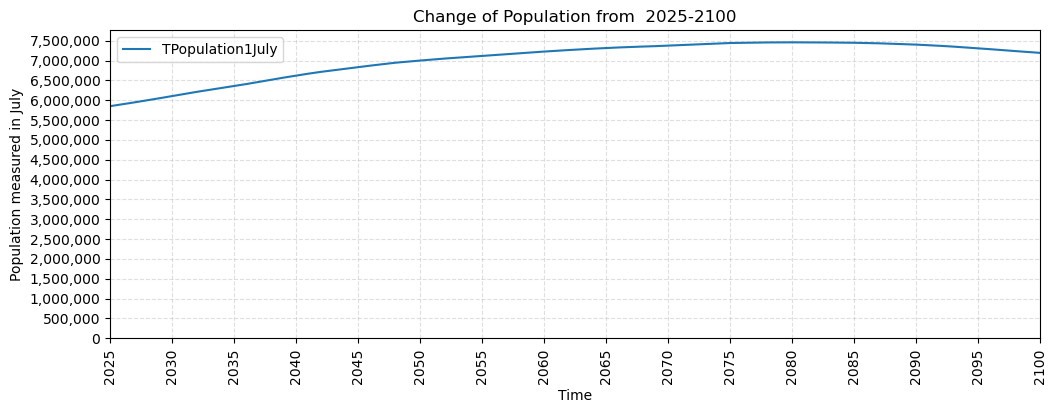

In [148]:
from matplotlib.ticker import FuncFormatter

df[["TPopulation1July","Time"]].sort_values("Time").plot(kind="line",x="Time",y="TPopulation1July",figsize=(12,4))
plt.xlabel("Time")
plt.ylabel("Population measured in July")
plt.title("Change of Population from  2025-2100")
plt.grid(True, linestyle='--', alpha=0.4)

plt.xlim(2025,2100)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(range(2025, 2105, 5),rotation=90);
plt.yticks(range(0,8000000,500000));

plt.savefig("Chart3_Population_Change1950-2100", bbox_inches='tight')




**2. Age Structure Analysis**

Is Lebanon getting older? 



In [149]:
df

,Time,TPopulation1July,PopGrowthRate,MedianAgePop,TFR,LEx,CBR,CDR,NetMigrations
61104,1950,1349350.0,2.786,21.9593,5.8054,59.8999,41.164,13.300,0.000
61105,1951,1387572.0,2.800,21.7235,5.8052,60.3297,41.119,13.130,0.000
61106,1952,1427085.0,2.816,21.4871,5.7989,60.7644,40.987,12.829,0.000
61107,1953,1468014.0,2.839,21.2387,5.8050,61.1769,40.899,12.512,0.000
61108,1954,1510416.0,2.856,20.9757,5.8062,61.5877,40.736,12.178,0.000
...,...,...,...,...,...,...,...,...,...
61250,2096,7284840.0,-0.329,46.9672,1.7541,87.1556,9.287,11.923,-4.769
61251,2097,7260714.0,-0.334,47.0932,1.7524,87.2673,9.262,12.036,-4.134
61252,2098,7237785.0,-0.298,47.1991,1.7480,87.3711,9.219,12.142,-0.418
61253,2099,7215744.0,-0.312,47.2873,1.7482,87.4796,9.207,12.229,-0.698


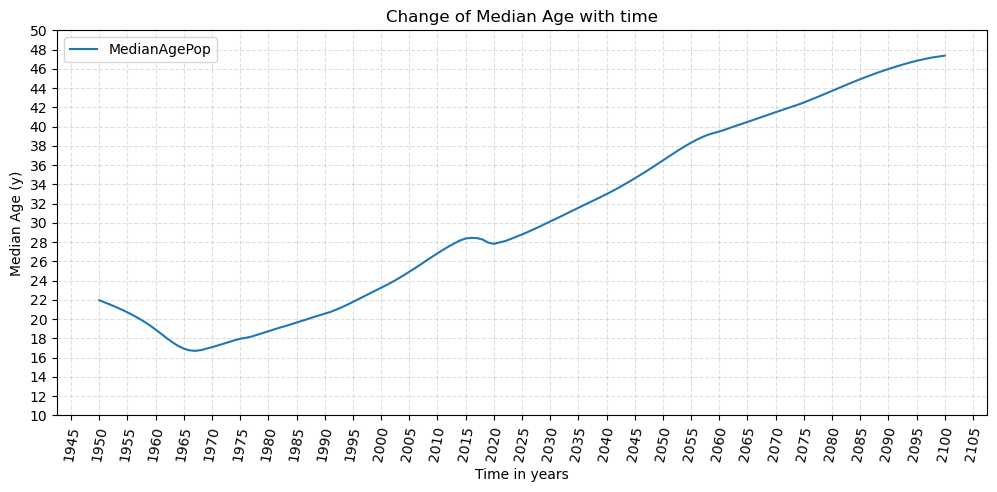

In [150]:
import numpy as np
df[["Time","MedianAgePop"]].sort_values("Time").plot(kind="line",
                                                     x="Time",
                                                     y="MedianAgePop",
                                                     figsize=(12,5)
                                                    )
plt.grid(True, linestyle='--', alpha=0.4)

plt.xlabel("Time in years")
plt.ylabel("Median Age (y)")
plt.xticks(range(1945,2110,5),rotation=80)
plt.yticks(np.arange(10,52,2)) 
plt.title("Change of Median Age with time")
plt.savefig("Chart4_Median_change", bbox_inches='tight')



The country is becoming older with time

**3. Fertility & Life Expectancy**  
How did fertility rate (TFR) drop?  
How did life expectancy improve?  


In [151]:
sorted(list(df_original["Location"].value_counts().index))

['ADB region: Central and West Asia',
 'ADB region: Developed',
 'ADB region: East Asia',
 'ADB region: South Asia',
 'ADB region: Southeast Asia',
 'ADB region: The Pacific',
 'AUKUS',
 'Afghanistan',
 'Africa',
 'African Group',
 'African Union',
 'African Union: Central Africa',
 'African Union: Eastern Africa',
 'African Union: Northern Africa',
 'African Union: Southern Africa',
 'African Union: Western Africa',
 'African, Caribbean and Pacific (ACP) Group of States',
 'Albania',
 'Algeria',
 'American Samoa',
 'Americas',
 'Andean Community',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Asia',
 'Asia-Pacific Economic Cooperation (APEC)',
 'Asia-Pacific Group',
 'Association of Southeast Asian Nations (ASEAN)',
 'Australia',
 'Australia/New Zealand',
 'Austria',
 'Azerbaijan',
 'BRIC',
 'BRICS',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Belt-Road Initiative (BRI)',
 'Belt-Road Initi

TFR: Total Fertility Rate - average kids per woman  
LEx: Life Expectancy at birth

In [152]:
df_World = df_original[df_original["Location"]=="World"].sort_values("Time")
df_LBN = df.sort_values("Time")
# merge is safe even with different lengths
df_temp = pd.merge(
    df_World[["Time","TFR","LEx"]].rename(columns={"TFR":"TFR_World","LEx":"LEx_World"}),
    df_LBN[["Time","TFR","LEx"]].rename(columns={"TFR":"TFR_LBN","LEx":"LEx_LBN"}),
    on="Time",
    how="inner"  # keeps all years from both
)
df_temp = df_temp.sort_values("Time").reset_index(drop=True)

df_temp.head()

,Time,TFR_World,LEx_World,TFR_LBN,LEx_LBN
0,1950,4.8519,46.3944,5.8054,59.8999
1,1951,4.8164,47.1259,5.8052,60.3297
2,1952,5.0008,48.2183,5.7989,60.7644
3,1953,4.9223,48.8090,5.8050,61.1769
4,1954,4.9978,49.6514,5.8062,61.5877


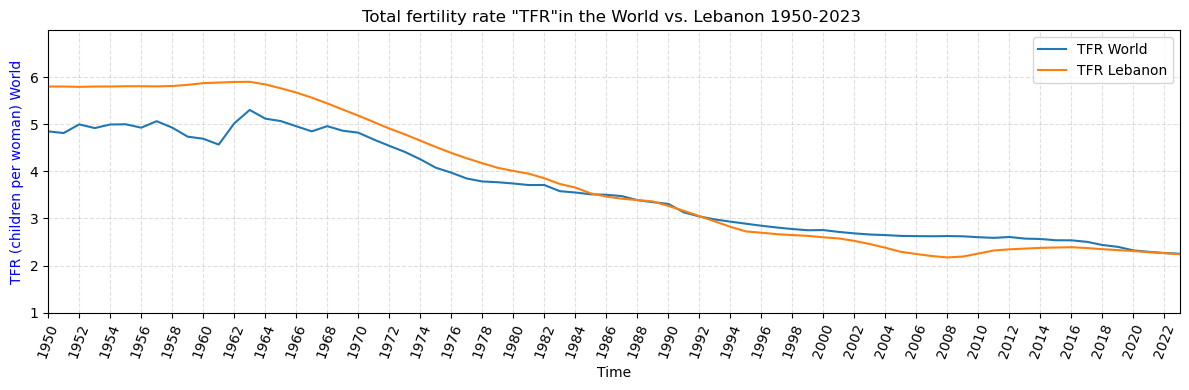

In [153]:
ax=df_temp[["Time","TFR_World","TFR_LBN"]].sort_values("Time").plot(kind="line",
                                                  x="Time",
                                                  figsize=(12,4))
plt.grid(True, linestyle='--', alpha=0.4)

ax.set_ylabel("TFR (children per woman) World", color='blue')
plt.xlabel("Time")
plt.title("Total fertility rate \"TFR\"in the World vs. Lebanon 1950-2023 ")
ax.legend(["TFR World","TFR Lebanon"])
plt.xticks(range(1950,2024,2),rotation=70)
plt.yticks(range(0,7,1))
plt.ylim(1,7)

plt.xlim(1950,2023)
plt.savefig("Chart5_comparison_TFR", bbox_inches='tight')

plt.tight_layout()
plt.show()



**Phase A:** 1950-1965 High and stable ∼5.8
Pre-transition  
rural society  
low contraception.

**Phase B:** 1965-1990 Rapid decline from 5.8 to 3.4  
This is the main drop  
Due to:  
Female education + Beirut urbanization  
Later marriage age - civil war 1975-1990 delayed family formation  
Contraception access  
Economic cost of children rising   

**Phase C:** 1990-2008  
Below replacement from 3.4 to 2.1  
Post-war, economic crisis, more women in workforce. Lebanon reached 2.1 (replacement level) around 2005.  

**Phase D:** 2008-2023 Stable low ∼2.2-2.4  
Slight bump 2008-2015 due to relative stability, then flat. Now slightly below replacement.

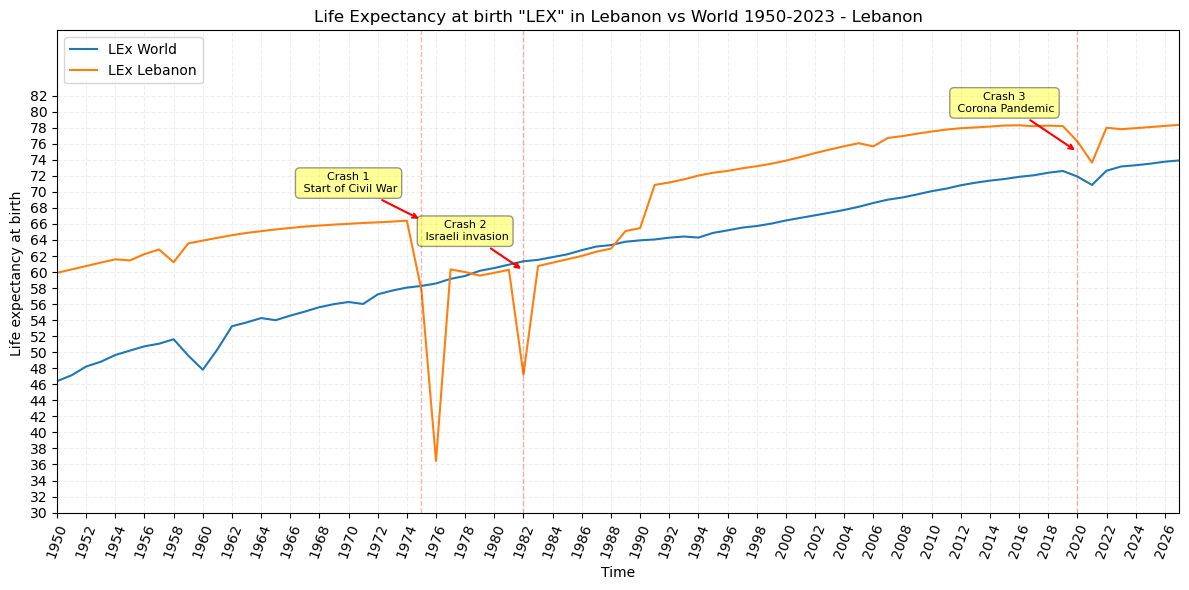

In [154]:
ax=df_temp[["Time","LEx_World","LEx_LBN"]].sort_values("Time").plot(kind="line",
                                                  x="Time",
                                                  figsize=(12,6))
plt.grid(True, linestyle='--', alpha=0.2)
ax.set_ylabel("Life expectancy at birth ")
ax.set_xlabel("Time")
plt.title("Life Expectancy at birth \"LEX\" in Lebanon vs World 1950-2023 - Lebanon")
ax.legend(["LEx World","LEx Lebanon"])
plt.xticks(range(1950, 2105, 2),rotation=70);
plt.yticks(range(30,84,2))
plt.xlim(1950,2027)

plt.annotate('Crash 1\n Start of Civil War',
             xy=(1975, 66.5), xytext=(1970,70),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=8, ha='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.4))
ax.axvline(x=1975, color='red', linestyle='--', linewidth=1, alpha=0.3)

plt.annotate('Crash 2\n Israeli invasion',
             xy=(1982, 60.2), xytext=(1978,64),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=8, ha='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.4))
ax.axvline(x=1982, color='red', linestyle='--', linewidth=1, alpha=0.3)

plt.annotate('Crash 3\n Corona Pandemic',
             xy=(2020, 75), xytext=(2015,80 ),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=8, ha='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.4))
ax.axvline(x=2020, color='red', linestyle='--', linewidth=1, alpha=0.3)

plt.savefig("Chart6_comparison_LEx", bbox_inches='tight')

plt.tight_layout()
plt.show()



**How did LEx improve?** 

1950-1974: Increase from 60 To 66 years 
- slow improvement, better healthcare, vaccines, less infant mortality.  
CRASH 1: 1975-1976: Dropped to 37 years 
- Start of Civil War. This is not biological, it's mortality spike from war deaths. 
CRASH 2: 1982: Dropped to 46 years 
- Israeli invasion of Lebanon, siege of Beirut.      
1990-1991: Jumped from 64 to 71 years 
- End of civil war. Healthcare system rebuilt, mortality drops instantly.      
1991-2019: Inclined from 71 to 78.5 years 
- Steady increase due to modern hospitals, lower infant mortality, better living standards.  
   
CRASH 3: 2020-2021: Declined 78.2 To 73.5 years - COVID-19 + Beirut port explosion (Aug 2020) + economic collapse.

Summary - Lebanon vs World LEx 1950-2023:  
1. 1950-1974  
Pre-war: Lebanon always +10y above World (60 vs 46.5). Stable growth.
2. 1975  
Civil War Start: LEx Lebanon crashes from 66.5 to 36.5y. Falls below World for first time.
3. 1982  
Israeli Invasion: Second crash from 60 to 47y. Again below World.
4. 1990-2019  
Post-war: Fast recovery to 78y. Gap with World shrinks from 13y to 5y - Lebanon gain advantage above the world
5. 2020-2021  
Lebanon dropped from 78.1 to 73.5y due to  COVID + Port Explosion + Economic Crisis  
World dropped from 72.4 to 71y due to pandemic.  
Lebanon drop is 3x larger.
6. 2022-2023  
Lebanon Rebound to 77.9y.

**TFR vs Replacement — Lebanon will never recover**

In [155]:
df_temp.head(3)

,Time,TFR_World,LEx_World,TFR_LBN,LEx_LBN
0,1950,4.8519,46.3944,5.8054,59.8999
1,1951,4.8164,47.1259,5.8052,60.3297
2,1952,5.0008,48.2183,5.7989,60.7644


In [156]:
df[["Time","TFR"]][df["TFR"]<=2.1].sort_values("TFR",ascending=False).head(2)

,Time,TFR
61186,2032,2.089
61187,2033,2.075


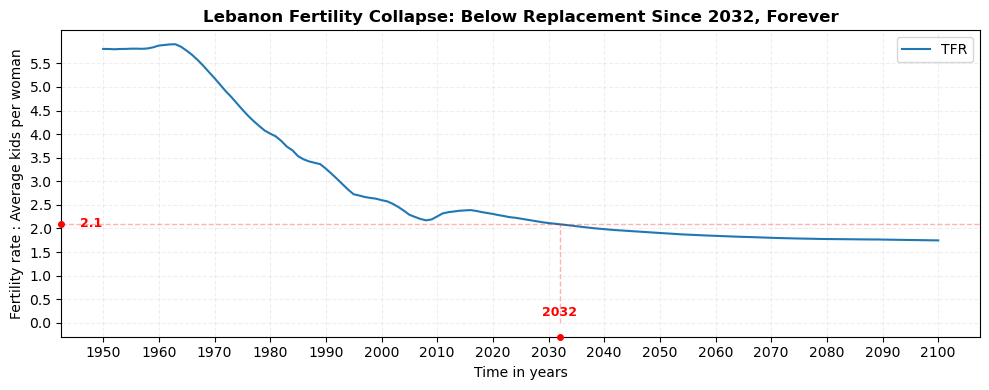

In [157]:
ax=df[["Time","TFR"]].sort_values("Time").plot(kind="line",x="Time",figsize=(10,4))
plt.xlabel("Time in years")
plt.ylabel("Fertility rate : Average kids per woman")
ax.set_title("Lebanon Fertility Collapse: Below Replacement Since 2032, Forever", fontweight='bold')
plt.grid(linestyle="--",alpha=0.2)
plt.yticks(np.arange(0,6,0.5));
plt.xticks(range(1950,2110,10))

ax.axhline(y=2.1, color='red', linestyle='--', linewidth=1, alpha=0.3)
ax.plot(0, 2.1, marker='o',color='red', markersize=4,transform=ax.get_yaxis_transform(), clip_on=False, zorder=5)
ax.text(0.02, 2.1, "2.1", color='red', fontweight='bold', fontsize=9,ha='left', va='center', transform=ax.get_yaxis_transform(), clip_on=False)

ax.vlines( x=2032, ymin=0, ymax=2.1, color='red', linestyle='--', linewidth=1, alpha=0.3)
ax.plot(2032, 0, marker='o', color='red', markersize=4, transform=ax.get_xaxis_transform(), clip_on=False, zorder=5)
ax.text(2032,0.1, "2032", color='red', fontweight='bold', fontsize=9, ha='center', va='top', transform=ax.get_xaxis_transform(), clip_on=False)

plt.savefig("Chart7_LBN_LEx", bbox_inches='tight')
plt.tight_layout()
plt.show()



What is TFR of 2:1 ?
It means each 2 parents are having 1 child, that is : replaced by one child.  
Why 2.1 and not 2.0?  
Parents need 2 children to replace them
0.1 extra because some children don't survive to adulthood, and slightly more boys are born than girls  
If TFR > 2.1 = each generation is bigger than the last  
If TFR < 2.1 = each generation is smaller than the last  
If TFR = 2.1 = population exactly replaces itself  

Once it is 2.1 for 25+ years, society can never recover because there is  fewer mothers in the next generation.  
That's why median age goes from 20 to 45.

**Median Age increase is caused by drop of fertility rate**

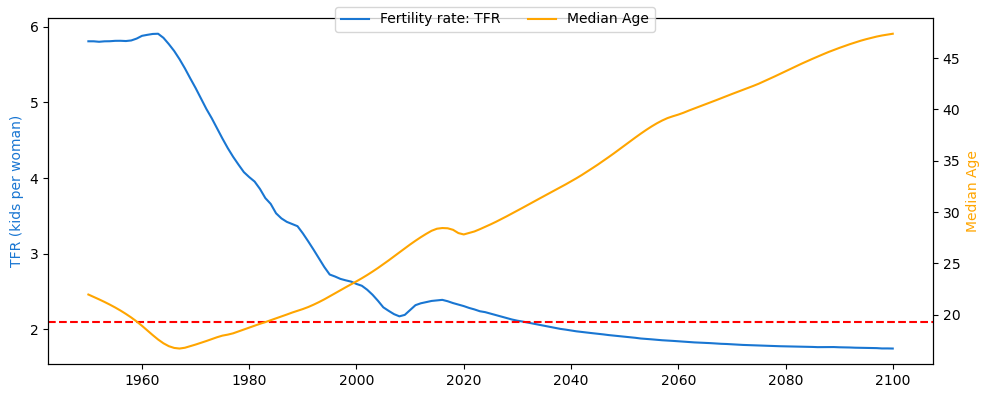

In [158]:
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(df['Time'], df['TFR'], color='#1976D2', label='Fertility rate: TFR')
ax1.axhline(2.1, color='red', linestyle='--')
ax1.set_ylabel("TFR (kids per woman)", color='#1976D2')

ax2 = ax1.twinx()
ax2.plot(df['Time'], df['MedianAgePop'], color='orange', label='Median Age')
ax2.set_ylabel("Median Age", color='orange')
fig.legend(loc='upper center', ncol=3)

plt.savefig("Chart8_TFR_Mdn", bbox_inches='tight')

plt.tight_layout()
plt.show()


We notice that the median age is inversly proportional to Fertility rate. And by lgic when no new borns are increasing, the median age increases.  
    So the median age increase is a consequence of decline in fertility rate.

**Population growth change**

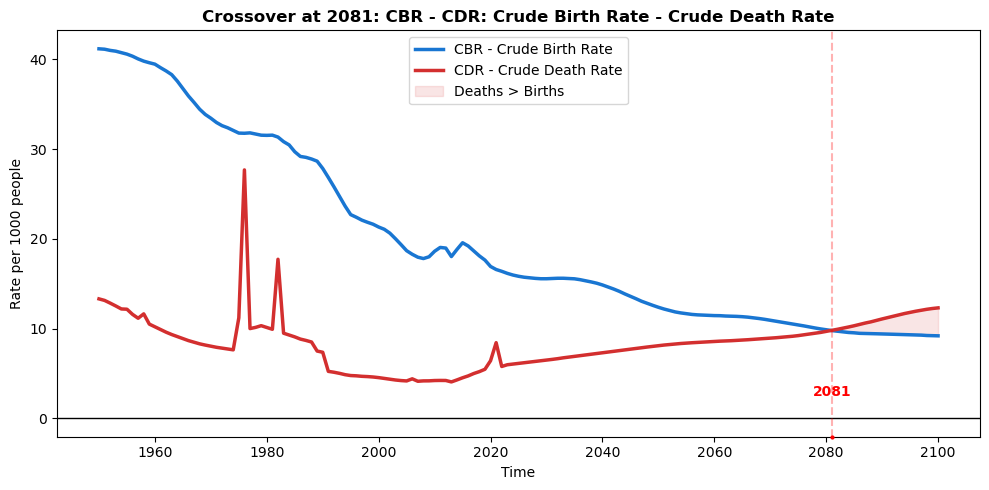

In [159]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df['Time'], df['CBR'], color='#1976D2', linewidth=2.5, label='CBR - Crude Birth Rate')
ax.plot(df['Time'], df['CDR'], color='#D32F2F', linewidth=2.5, label='CDR - Crude Death Rate')
ax.axhline(y=0, color='black', linewidth=1)
ax.fill_between(df['Time'], df['CBR'], df['CDR'], where=(df['CDR']>df['CBR']), color='#D32F2F', alpha=0.12, label='Deaths > Births')

crossover = df[df['CBR'] < df['CDR']].sort_values("Time").head(1)["Time"].values[0]
ax.axvline(x=crossover, color='red', linestyle='--', alpha=0.3)
ax.plot(crossover, 0, marker='o', color='red', markersize=2, transform=ax.get_xaxis_transform(), clip_on=False, zorder=5)
ax.text(crossover, 0.1, f"{int(crossover)}", color='red', fontweight='bold', ha='center', transform=ax.get_xaxis_transform(), clip_on=False)

ax.set_title("Crossover at {}: CBR - CDR: Crude Birth Rate - Crude Death Rate".format(int(crossover)), fontweight='bold')
ax.set_ylabel("Rate per 1000 people")
ax.set_xlabel("Time")
ax.legend()

plt.savefig("Chart9_CBR_CDR", bbox_inches='tight')

plt.tight_layout()
plt.show()


df['NaturalIncrease'] = df['CBR'] - df['CDR']  
Why: Natural Increase = births - deaths per 1000. If this is >0, population grows naturally. If <0, more people die than are born. That's the core of depopulation.

In [160]:
crossover = df[df['CBR'] < df['CDR']].sort_values("Time").head(1)
crossover

,Time,TPopulation1July,PopGrowthRate,MedianAgePop,TFR,LEx,CBR,CDR,NetMigrations
61235,2081,7457546.0,-0.015,43.9608,1.774,85.4813,9.77,9.789,-0.973


**Immigration Curve**

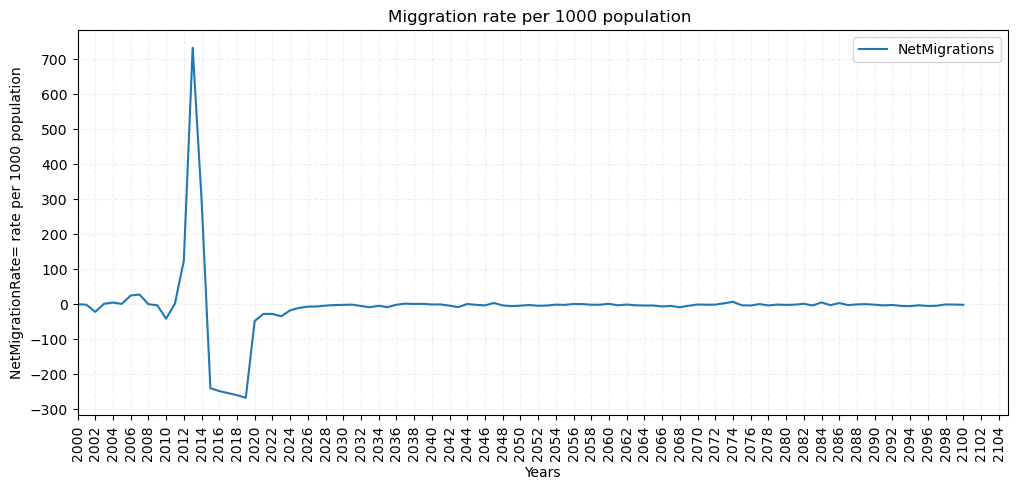

In [161]:
df[["Time","NetMigrations"]].sort_values("Time").plot(kind="line",
                                               x="Time",
                                               y="NetMigrations",
                                               figsize=(12,5))
plt.xticks(range(1950, 2105, 2),rotation=90);
plt.xlim(2000,2105)
plt.yticks(range(-300, 800, 100));
plt.grid(True,linestyle="--",alpha=0.2)

plt.xlabel("Years")
plt.ylabel("NetMigrationRate= rate per 1000 population")
plt.title("Miggration rate per 1000 population ")
plt.savefig("Chart10_Immigration1950_2100", bbox_inches='tight')

                                               
                                               #: Immigrants - Emigrants (negative = people leaving Lebanon)

2019 
economic crisis starts  
- Banks freeze dollars  
-Lira devalues 90%, this means People WANT to leave but CAN'T afford ticket + visa.  
So outflow drops from -270 to -150.  
    
2020-2021  
COVID travel bans  
- Airports closed. Both in and out = 0. Net rate goes from -250 to -30 automatically because Immigrants = 0 and Emigrants = 0, so Net = 0.

2022+  
UN projection smooths to 0  
-UN WPP 2024 assumes migration returns to normal long-term average -0.9 per 1000  So they model it as flat near 0

**Will Immigration helps to fill the gap of depopulation?**

C:\Users\pc\AppData\Local\Temp\ipykernel_14188\3992979839.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Pop-difference-rate'] = df['CBR'] - df['CDR']
C:\Users\pc\AppData\Local\Temp\ipykernel_14188\3992979839.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total'] = df['Pop-difference-rate'] + df['NetMigrations'] # change to your column name


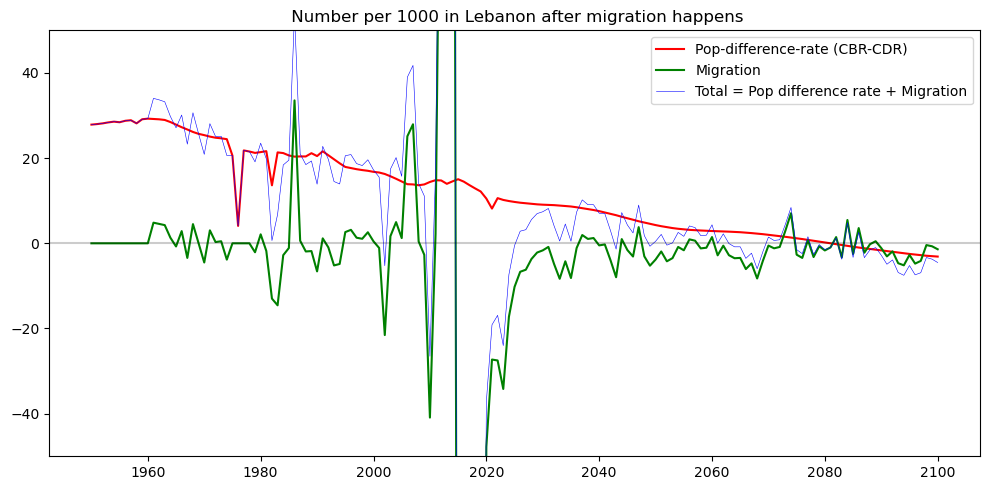

In [162]:
df['Pop-difference-rate'] = df['CBR'] - df['CDR']
df['Total'] = df['Pop-difference-rate'] + df['NetMigrations'] # change to your column name

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df['Time'], df['Pop-difference-rate'], color='red', label='Pop-difference-rate (CBR-CDR)')
ax.plot(df['Time'], df['NetMigrations'], color='green', label='Migration')
ax.plot(df['Time'], df['Total'], color='blue', linewidth=0.4, label='Total = Pop difference rate + Migration')

ax.axhline(0, color='black',alpha=0.2)
plt.ylim(-50,50)
plt.title(" Number per 1000 in Lebanon after migration happens")
plt.legend()

plt.savefig("Chart11_Total", bbox_inches='tight')

plt.tight_layout()
plt.show()


Total growth = Pop-difference-rate + Migration.  
After 2019 Pop-difference-rate dropped to ∼3 per 1000, so it could no longer absorb migration shocks.  
In 2020 Migration was ~-50 per 1000, so Total became -47 — the loss increased.  
For 2024-2100 UN projects Migration ∼0, but Pop-difference-rate goes negative after 2045, so Total stays negative.  



**Conclusion**  
No, Migration won't fill the gap, and the population growth won't absorb migration loss

import os
print(os.getcwd())